# Install & Imports

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import requests
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# Download Dataset and Preprocess

In [12]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text

print("Total characters:", len(text))
print(text[:500])

chars = sorted(list(set(text)))

vocab_size = len(chars)

print("Vocabulary Size:", vocab_size)

char_to_idx = {ch:i for i,ch in enumerate(chars)}
idx_to_char = {i:ch for i,ch in enumerate(chars)}

encoded_text = [char_to_idx[c] for c in text]

Total characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
Vocabulary Size: 65


# Create Sequences

In [13]:
SEQ_LEN = 100

X = []
Y = []

for i in range(len(encoded_text) - SEQ_LEN):
    X.append(encoded_text[i:i+SEQ_LEN])
    Y.append(encoded_text[i+1:i+SEQ_LEN+1])

X = np.array(X)
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(1115294, 100)
(1115294, 100)


# Dataset & DataLoader

In [14]:
class TextDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = TextDataset(X, Y)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

# Common Model Architecture

In [15]:
class TextGenerator(nn.Module):

    def __init__(self,
                 vocab_size,
                 embedding_dim=128,
                 hidden_dim=256,
                 num_layers=2,
                 model_type="RNN"):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        if model_type == "RNN":
            self.rnn = nn.RNN(
                embedding_dim,
                hidden_dim,
                num_layers=num_layers,
                batch_first=True
            )

        elif model_type == "LSTM":
            self.rnn = nn.LSTM(
                embedding_dim,
                hidden_dim,
                num_layers=num_layers,
                batch_first=True
            )

        elif model_type == "GRU":
            self.rnn = nn.GRU(
                embedding_dim,
                hidden_dim,
                num_layers=num_layers,
                batch_first=True
            )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        output = self.fc(output)

        return output

# Training Function

In [16]:
def train_model(model_type, epochs=10):

    model = TextGenerator(
        vocab_size=vocab_size,
        model_type=model_type
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        epoch_loss = 0

        model.train()

        for x_batch, y_batch in loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(x_batch)

            loss = criterion(
                outputs.reshape(-1, vocab_size),
                y_batch.reshape(-1)
            )

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)

        losses.append(avg_loss)

        print(
            f"{model_type} | Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}"
        )

    return model, losses

# Train Vanilla RNN

In [17]:
rnn_model, rnn_loss = train_model(
    model_type="RNN",
    epochs=10
)

RNN | Epoch 1/10 | Loss: 1.3001
RNN | Epoch 2/10 | Loss: 1.1481
RNN | Epoch 3/10 | Loss: 1.1180
RNN | Epoch 4/10 | Loss: 1.1069
RNN | Epoch 5/10 | Loss: 1.1016
RNN | Epoch 6/10 | Loss: 1.0984
RNN | Epoch 7/10 | Loss: 1.0964
RNN | Epoch 8/10 | Loss: 1.0945
RNN | Epoch 9/10 | Loss: 1.0931
RNN | Epoch 10/10 | Loss: 1.0920


# Train LSTM

In [18]:
lstm_model, lstm_loss = train_model(
    model_type="LSTM",
    epochs=10
)

LSTM | Epoch 1/10 | Loss: 1.2482
LSTM | Epoch 2/10 | Loss: 0.9029
LSTM | Epoch 3/10 | Loss: 0.7479
LSTM | Epoch 4/10 | Loss: 0.6733
LSTM | Epoch 5/10 | Loss: 0.6325
LSTM | Epoch 6/10 | Loss: 0.6072
LSTM | Epoch 7/10 | Loss: 0.5893
LSTM | Epoch 8/10 | Loss: 0.5760
LSTM | Epoch 9/10 | Loss: 0.5657
LSTM | Epoch 10/10 | Loss: 0.5572


# Train GRU

In [19]:
gru_model, gru_loss = train_model(
    model_type="GRU",
    epochs=10
)

GRU | Epoch 1/10 | Loss: 1.1304
GRU | Epoch 2/10 | Loss: 0.8774
GRU | Epoch 3/10 | Loss: 0.8198
GRU | Epoch 4/10 | Loss: 0.7927
GRU | Epoch 5/10 | Loss: 0.7757
GRU | Epoch 6/10 | Loss: 0.7634
GRU | Epoch 7/10 | Loss: 0.7539
GRU | Epoch 8/10 | Loss: 0.7465
GRU | Epoch 9/10 | Loss: 0.7404
GRU | Epoch 10/10 | Loss: 0.7352


 # Loss Comparison Graph

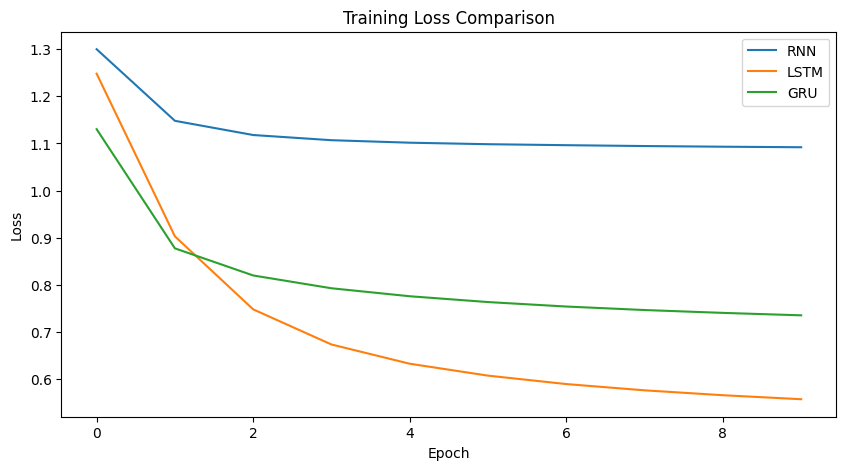

In [20]:
plt.figure(figsize=(10,5))

plt.plot(rnn_loss,label="RNN")
plt.plot(lstm_loss,label="LSTM")
plt.plot(gru_loss,label="GRU")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.legend()

plt.show()

# Text Generation Function

In [21]:
def generate_text(model,
                  start_text,
                  length=300):

    model.eval()

    chars_input = [char_to_idx[c] for c in start_text]

    input_seq = torch.tensor(
        chars_input,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    generated = start_text

    for _ in range(length):

        with torch.no_grad():

            output = model(input_seq)

            probs = torch.softmax(
                output[0,-1],
                dim=0
            )

            next_char_idx = torch.multinomial(
                probs,
                1
            ).item()

        generated += idx_to_char[next_char_idx]

        input_seq = torch.cat(
            [
                input_seq,
                torch.tensor([[next_char_idx]]).to(device)
            ],
            dim=1
        )

        input_seq = input_seq[:, -SEQ_LEN:]

    return generated

# Generate Text Using RNN

In [22]:
print(
    generate_text(
        rnn_model,
        "KING",
        length=400
    )
)

KINGHAM:
Mark hear us, nor so house: the harsh-faced with her roar or no treat princes I know,--

Shepherd:
I'll enter in, and
till it not so heaving envicines!
Joruge I'll bring me in chaste.

MIRANDA:
And I not, instance he is but cries;
For violent furnoseth sound.
Live an o'ergrown,
Not fly:
Unto the lute,
To presued their allied, thy noble house
Playon or Clarence,
That would you were well compla


# Generate Text Using LSTM

In [23]:
print(
    generate_text(
        lstm_model,
        "KING",
        length=400
    )
)

KING HENRY VI:
Where is he body that she cry 'banishment?

MARCIUS:
Let the public benefactors: so that I am banished.

VIRGILIA:
I thank you both.
Were you shall grut us all withal eyes!

RICHARD:
I was, but yet my county strike York,
In morail, truly, I have not so much:
I'll play the honour'd roof. Therefore, I pray you,
God keep your worship: but murders, hath none tears,
He shortens flame in a li


# Generate Text Using GRU

In [24]:
print(
    generate_text(
        gru_model,
        "KING",
        length=400
    )
)

KINGHAM:
Good time of day is too, and I should wish
You chose him, I'll cram the fear to tell your love.
Marry, my heaven we'll to the hill;
And Heaven, in gold-sworn than I would wish
Your hand; was in difference; but that I should have
displeasure of the Duke of Buckingham tog!
The noble duke have smiling, wife is away;
For this cannibances, service is with one.

BRUTUS:
God's good worship, sir, to 
